# 06 - COVID-19 Geographical Analysis

Here, we are going to analyze if there are **structural differences between continents or regions**.

We are going to analyze:

* Comparisons between continents:
    - Cases per capita
    - Deaths per capita
    - Median age

* Boxplots/Violin
* Map (if not too complex)

## Import Libraries

In [1]:
import os
from pathlib import Path

project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent
os.chdir(project_root)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import the data loader module
from src.data_loader import change_dtypes
from src.visualization import set_style

# Set visualization style
set_style(palette="Blues_d")

print('Libraries imported successfully!')

Libraries imported successfully!


## Load Data

In [3]:
countries = pd.read_csv("data/processed/countries.csv", parse_dates=["date"])
countries.head()

,country,date,total_cases,new_cases,new_cases_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths,new_deaths,...,continent,population,population_density,median_age,life_expectancy,gdp_per_capita,extreme_poverty,diabetes_prevalence,handwashing_facilities,hospital_beds_per_thousand
0,Afghanistan,2020-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Asia,40578847.0,62.215549,16.752001,65.616997,1516.273315,2.436315,10.9,51.938343,0.39
1,Afghanistan,2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Asia,40578847.0,62.215549,16.752001,65.616997,1516.273315,2.436315,10.9,51.938343,0.39
2,Afghanistan,2020-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Asia,40578847.0,62.215549,16.752001,65.616997,1516.273315,2.436315,10.9,51.938343,0.39
3,Afghanistan,2020-01-04,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,...,Asia,40578847.0,62.215549,16.752001,65.616997,1516.273315,2.436315,10.9,51.938343,0.39
4,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,...,Asia,40578847.0,62.215549,16.752001,65.616997,1516.273315,2.436315,10.9,51.938343,0.39


## Geographical Analysis

Until now, we have worked with time series data. Now we need a fixed photo of the final state for each continent or region.

In [ ]:
# Group by country and select the info we need
country_stats = (
    countries
    .groupby("country")
    .agg({
        'continent': 'first',
        'population': 'first',
        'gdp_per_capita': 'first',
        'median_age': 'first',
        'total_cases_per_million': 'max',
        'total_deaths_per_million': 'max',
        'people_fully_vaccinated_per_hundred': 'max'
    })
    .reset_index()
)

# We drop countries without data in population or total_deaths_per_million
country_stats = country_stats.dropna(subset=['total_deaths_per_million', 'population'])

print(f"Analysis dataset ready with {country_stats.shape[0]} countries.")
country_stats.head()

Analysis dataset ready with 232 countries.


,country,continent,population,gdp_per_capita,median_age,total_cases_per_million,total_deaths_per_million,people_fully_vaccinated_per_hundred
0,Afghanistan,Asia,40578847.0,1516.273315,16.752001,5295.3696,194.48557,34.659077
1,Albania,Europe,2827614.0,15492.067383,35.943001,118152.6200,1274.57290,45.168964
2,Algeria,Africa,45477391.0,11198.233398,27.983000,5974.6610,151.30595,14.251447
3,American Samoa,Oceania,48365.0,5579.981445,27.927000,172211.3100,702.98770,NaN
4,Andorra,Europe,79722.0,40223.011719,42.832001,601766.1000,1994.43070,67.103180


### Continent Analysis
We need to see the distribution of each continent in comparison with the others.

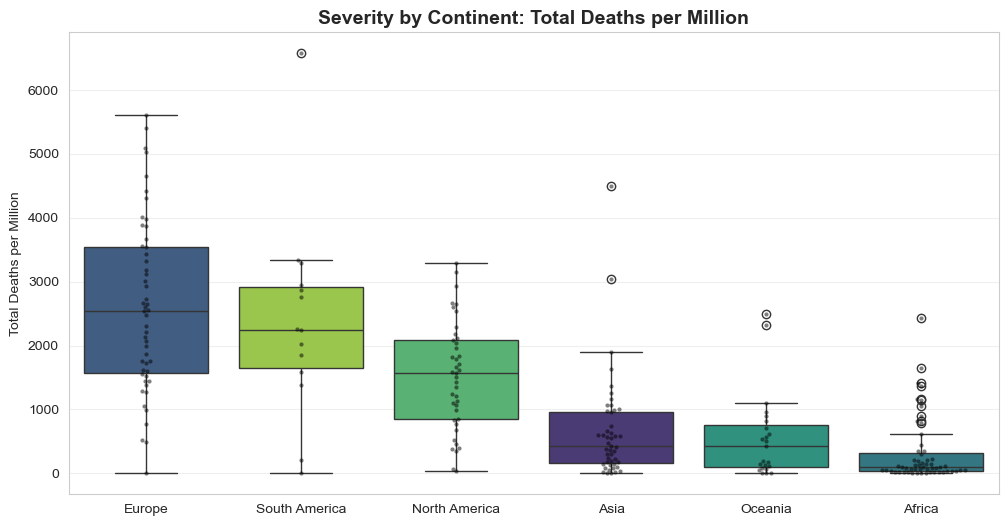

In [14]:
plt.figure(figsize=(12, 6))

# Order by median of total_deaths_per_million
order_list = (
    country_stats
    .groupby('continent')['total_deaths_per_million']
    .median()
    .sort_values(ascending=False)
    .index
)

# BOXPLOT
sns.boxplot(
    data=country_stats, 
    x='continent', 
    y='total_deaths_per_million',
    palette='viridis',
    hue="continent",
    order=order_list,
    legend=False
)

# SWARMPLOT: INCLUDE REAL POINTS
sns.swarmplot(
    data=country_stats, 
    x='continent', 
    y='total_deaths_per_million',
    order=order_list,
    color='black',
    alpha=0.5,
    size=3
)

plt.title('Severity by Continent: Total Deaths per Million', fontsize=14, fontweight='bold')
plt.ylabel('Total Deaths per Million')
plt.xlabel('')
plt.grid(axis='y', alpha=0.3)

plt.show()

In [47]:
country_stats.sort_values(by="total_deaths_per_million", ascending=False).head(5)

,country,continent,population,gdp_per_capita,median_age,total_cases_per_million,total_deaths_per_million,people_fully_vaccinated_per_hundred
166,Peru,South America,33475436.0,12743.942383,29.096001,134460.69,6575.6274,85.587135
31,Bulgaria,Europe,6825862.0,26961.291016,44.153999,189530.64,5607.0576,30.434149
156,North Macedonia,Europe,1840236.0,17128.759766,39.910000,189219.75,5399.8510,45.542255
26,Bosnia and Herzegovina,Europe,3204802.0,16737.226562,44.558998,125713.54,5097.6626,26.400383
94,Hungary,Europe,9684308.0,35356.777344,42.993000,227311.55,5035.9820,64.090385


In [ ]:
continent_analysis = (
    country_stats
    .groupby("continent")
    .agg({
        "median_age": "mean",
        "total_deaths_per_million": "median",
        "gdp_per_capita": "median",
        "population": "median"
    })
    .sort_values("total_deaths_per_million", ascending=False)
)

continent_analysis

,median_age,total_deaths_per_million,gdp_per_capita,population
continent,,,,
Europe,42.102647,2532.973000,40223.011719,5110015.0
South America,30.221786,2250.823250,15093.464844,14950528.0
North America,35.766414,1572.428600,20718.388672,185350.0
Asia,29.028489,433.293700,14740.009766,20034612.0
Oceania,28.234087,424.003600,5579.981445,112122.0
Africa,20.902643,101.823403,3435.171631,13486063.5


* **Europe (High Variance):**
    Europe shows the largest Interquartile Range (IQR), indicating extreme variability in management. While it suffered from an aging population structure, the disparity suggests that political decisions and healthcare capacity made a massive difference between nations (e.g., Western vs. Eastern Europe).

* **Africa (The Demographic Shield):**
    The low mortality rates in Africa are striking. While **under-reporting bias** is a significant factor due to testing limitations, we must acknowledge the **"Demographic Dividend"**: with a median age of ~20 years (vs. ~42 in Europe), the population possesses a natural biological resistance to severe COVID-19 outcomes. The outliers here likely represent countries with better transparency or older demographics (e.g., South Africa).

* **Asia & Oceania (Top Performers):**
    These regions display distributions closest to zero. Oceania benefited from geographical isolation (island nations), while many Asian countries likely capitalized on prior epidemic experience (SARS/MERS) and cultural adherence to non-pharmaceutical interventions (masks).

* **The Americas (The Hotspot):**
    North and South America show high severity. Notably, South America contains the single country with the highest mortality rate in the world (Peru), highlighting the catastrophic combination of high urbanization, inequality, and healthcare collapse.

### Did richer countries influence pandemic management?

In [41]:
continent_analysis

,median_age,total_deaths_per_million,gdp_per_capita,population
continent,,,,
Europe,42.102647,2532.973000,40223.011719,5110015.0
South America,30.221786,2250.823250,15093.464844,14950528.0
North America,35.766414,1572.428600,20718.388672,185350.0
Asia,29.028489,433.293700,14740.009766,20034612.0
Oceania,28.234087,424.003600,5579.981445,112122.0
Africa,20.902643,101.823403,3435.171631,13486063.5


The data reveals a **counter-intuitive positive correlation**: countries with higher GDP per Capita often reported *higher* mortality rates. Does this mean wealth is detrimental to pandemic management? **No.**

This phenomenon, often called the **"Wealth Paradox"**, is explained by structural factors rather than management failure:

1.  **The Demographic Trap (Confounding Variable):**
    There is a strong correlation between GDP and Median Age. Wealthy nations (Europe, North America) have significantly older populations (Median Age > 40), which is the primary risk factor for COVID-19 mortality. In contrast, emerging economies with younger populations had a natural biological shield.

2.  **Surveillance & Reporting Bias:**
    Wealthy nations possess advanced healthcare systems capable of testing and attributing deaths accurately. Lower-income nations likely suffered from significant **under-reporting**, making their statistics appear artificially low.

3.  **Global Connectivity:**
    High-GDP nations are global travel hubs, leading to earlier and faster viral seeding before containment measures could be established.

**Verdict:** While wealth provided better resources (vaccines, ICU capacity), it could not fully offset the vulnerability of an aging population and the transparency of rigorous reporting.

### Relative Severity

The objective here is to analyze the residuals of a linear regression. As median age is our best predictor (see bivariate analysis), we can calculate the residuals (expected performande - real one). This allows us to see which countries have been top or worse taking into account their expected deaths explained by median age.

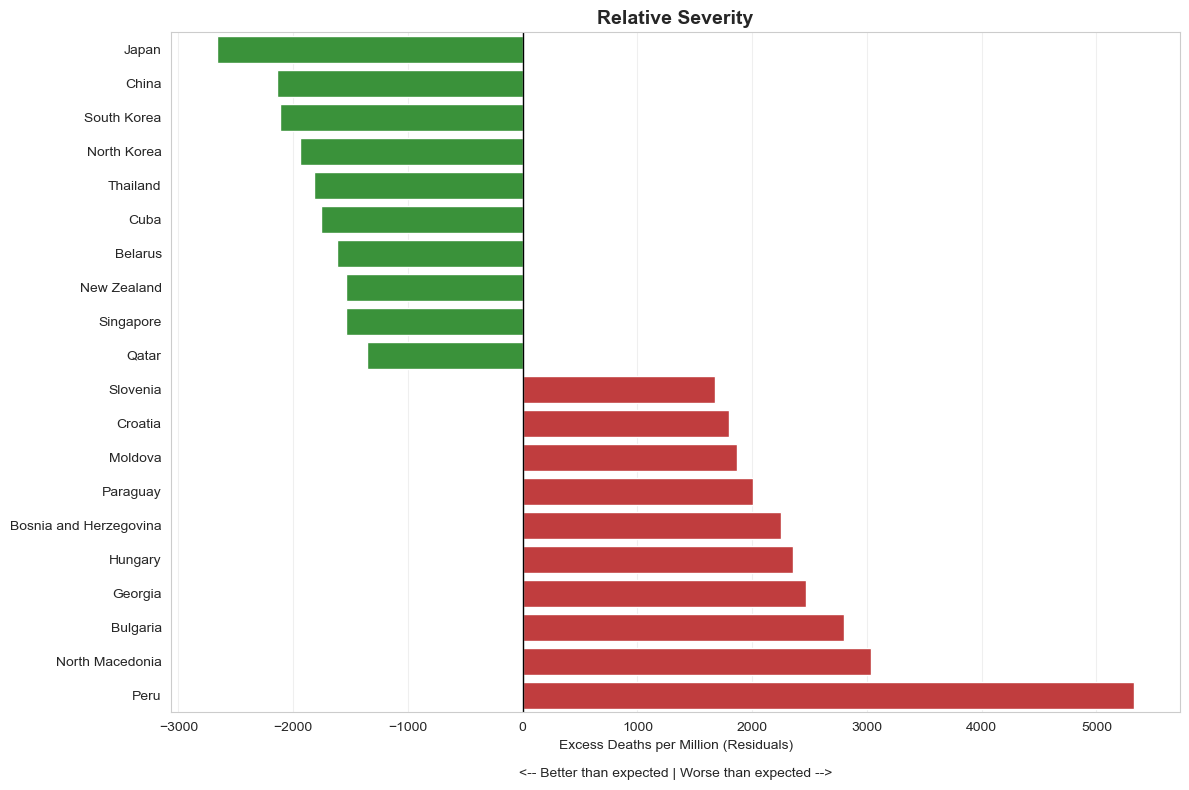

In [45]:
df_reg = country_stats[country_stats['population'] > 1000000].copy()

df_reg = df_reg.dropna(subset=['median_age', 'total_deaths_per_million'])

# Linear Regression
# y = mx + b
x = df_reg['median_age']
y = df_reg['total_deaths_per_million']
slope, intercept = np.polyfit(x, y, 1)

# 3. "Expected Deaths" and "Residual"
df_reg['expected_deaths'] = (slope * df_reg['median_age']) + intercept
df_reg['performance_score'] = df_reg['total_deaths_per_million'] - df_reg['expected_deaths']

# 4. Top and bottom
# OBSERVATION: "Better" means NEGATIVE residuals (less deaths than expected)
top_performers = df_reg.nsmallest(10, 'performance_score')
worst_performers = df_reg.nlargest(10, 'performance_score')

ranking = pd.concat([top_performers, worst_performers]).sort_values('performance_score')

# 5. Visualization
plt.figure(figsize=(12, 8))

colors = ['tab:green' if x < 0 else 'tab:red' for x in ranking['performance_score']]

sns.barplot(x='performance_score', y='country', data=ranking, palette=colors, hue="country", legend=False)

plt.axvline(x=0, color='black', linestyle='-', linewidth=1) # Línea central
plt.title('Relative Severity', fontsize=14, fontweight='bold')
plt.xlabel('Excess Deaths per Million (Residuals)\n\n<-- Better than expected | Worse than expected -->')
plt.ylabel('')
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [49]:
display(ranking)

,country,continent,population,gdp_per_capita,median_age,total_cases_per_million,total_deaths_per_million,people_fully_vaccinated_per_hundred,expected_deaths,performance_score
105,Japan,Asia,1.249976e+08,41837.910156,48.548000,269717.340,596.347530,82.705180,3259.043972,-2662.696442
42,China,Asia,1.425180e+09,18187.841797,38.534000,69638.510,84.874214,90.127560,2223.320472,-2138.446258
199,South Korea,Asia,5.178252e+07,45560.125000,43.944000,601957.750,665.997000,85.641710,2782.863513,-2116.866513
155,North Korea,Asia,2.632884e+07,14740.009766,35.805000,0.000,0.000000,NaN,1941.066673,-1941.066673
211,Thailand,Asia,7.173532e+07,17507.621094,39.194000,65968.914,473.365140,74.560320,2291.582641,-1818.217501
50,Cuba,North America,1.105982e+07,20718.388672,41.505001,100642.484,771.260130,90.536430,2530.603799,-1759.343669
18,Belarus,Europe,9.173240e+06,19092.111328,40.192001,108362.695,775.952640,69.269550,2394.803451,-1618.850811
150,New Zealand,Oceania,5.131731e+06,45185.312500,37.068001,438729.160,533.153440,83.630980,2071.695722,-1538.542282
192,Singapore,Asia,5.649888e+06,108036.109375,34.877998,419185.840,306.908750,90.638410,1845.189130,-1538.280380
172,Qatar,Asia,2.892466e+06,96557.812500,32.458000,175631.110,238.550770,98.605034,1594.894644,-1356.343874


**Top Performers**

* We can see here countries in Asia as top performers, meaning that in that continent, countries adopted a good management taking into account the median age of their population.

* Shoutout to Cuba, having an old population and performing impressive vaccination performance, they are a country that managed COVID-19 in an outstanding way.

* Belraus was also a top performer and they had an old population and did not vaccinate as much as other top performers, being the country in the top with less pepople fully vaccinated.

* Other remarkable country is Qatar, being in the top due to their 98% of people fully vaccinated, which demonstrates an aware population.

> Careful: North Korea has not reported any case or death, so that country must not be taken into account for our analysis.

<br>

**Worse Performers**

* Most of worse performers are countries in Eastern Europe, as we could see in the boxplot of before. But these countries tend to have a pretty old population, so they were more susceptible to the virus.

* The countries in South America were the ones with poorer management. We say this because they had younger populations (Paraguay≈26 and Peru≈29 years old) and they still performed bad. It is worth highlighting that Peru was the worst performer of all, being the country with more deaths reported and one of the youngest.

* There is just one worse performer in Asia, Georgia. They have a young population also, around 37 years old, and they reported a lot of deaths.

### Peaks Intensity

Which regions faced the most violent surges? 

Instead of looking at total sums, we look at the **maximum daily deaths (smoothed) per million**. 

This represents the "Height of the Wave" and the stress on healthcare systems.

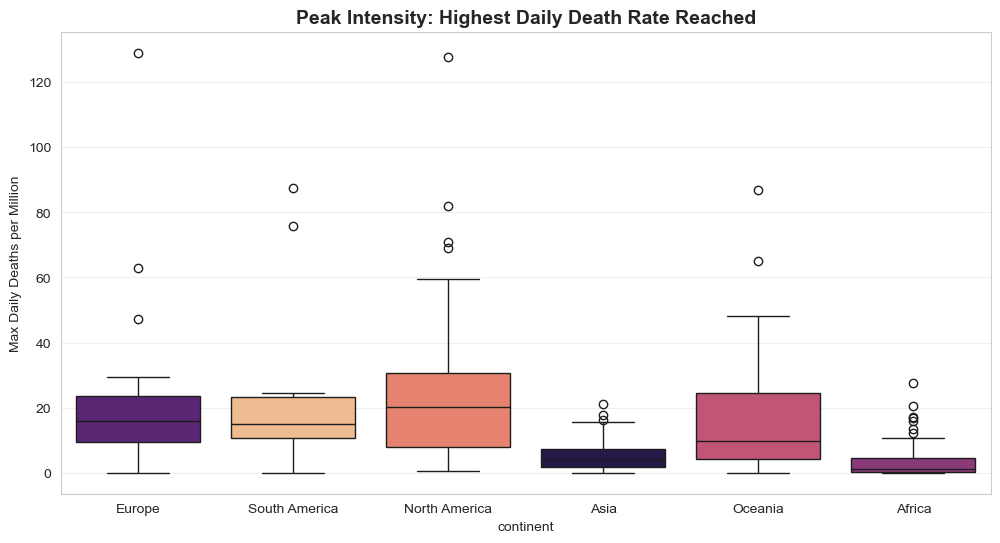

In [52]:
peak_intensity = (
    countries
    .groupby("country")
    .agg({
        'continent': 'first',
        'new_deaths_smoothed_per_million': 'max' # El punto más alto de su peor ola
    })
    .reset_index()
).dropna()


plt.figure(figsize=(12, 6))
sns.boxplot(
    data=peak_intensity, 
    x='continent', 
    y='new_deaths_smoothed_per_million',
    hue='continent',
    legend=False,
    palette='magma',
    order=order_list
)

plt.title('Peak Intensity: Highest Daily Death Rate Reached', fontsize=14, fontweight='bold')
plt.ylabel('Max Daily Deaths per Million')
plt.grid(axis='y', alpha=0.3)
plt.show()

#### **North America**
Surprisingly, North America shows the highest median `Max Daily Deaths per Million`. This suggests that when waves hit, they were particularly violent and concentrated. 

However, as noted in the previous analysis, North America managed to keep cumulative deaths lower than South America or Europe in several regions, indicating a system that faced extreme "stress tests" but avoided the sustained high mortality rates seen elsewhere.

#### **Europe & South America**
These continents show similar peak distributions, but their "bad performers" (outliers) are the most extreme.

In **Europe**, the peaks were high due to the demographic vulnerability of an older population. In **South America**, the intensity was compounded by healthcare saturation, leading to some of the highest and most tragic peaks globally (Peru, Paraguay).

#### **Asia, Oceania & Africa**
The lower peak intensity in these regions supports the "Top Performer" status of Asia and Oceania. By keeping the peaks low (flattening the curve), they prevented the collapse of healthcare infrastructure. 

In **Africa**, the low intensity reinforces the demographic shield theory—even at the virus's worst moments, the young population prevented the "explosive" daily mortality rates seen in more aged societies (obviously taking into account the report bias).

## Summary

In this notebook, we moved from the timeline to the map to understand the structural and regional differences in the pandemic's impact.

**1. Continent Analysis & Severity**
* **South America & Europe:** These regions suffered the highest mortality burden. However, the causes differ: Europe struggled due to its **aged population** (Median Age ~42), while South America faced a combination of healthcare saturation and high inequality despite a younger demographic.

* **Africa & Asia:** They appear as the regions with the lowest mortality. This validates the **"Demographic Shield"** theory for Africa (Median Age ~19) and highlights the effectiveness of containment strategies in many Asian nations.

<br>

**2. The Wealth Paradox (GDP vs. Deaths)**
* We debunked the assumption that "Rich Countries = Fewer Deaths". The data shows a **positive correlation** between GDP and Mortality.

* **Explanation:** Wealth acts as a proxy for an **older population** (the main risk factor) and better **reporting systems**. Wealthy nations didn't necessarily manage the pandemic worse; they simply had more vulnerable populations and counted them more accurately.

<br>

**3. Relative Performance (Residual Analysis)**
* By filtering out the effect of age, we identified the true outliers:

    * **Top Performers:** Asian and Oceanian countries (like South Korea, New Zealand) consistently showed negative residuals, meaning they saved more lives than their demographics predicted.

    * **Worse Performers:** Eastern European and South American nations (notably Peru) showed the highest positive residuals, indicating excess mortality beyond what their age structure would predict.

<br>

**4. Peak Intensity**
* **North America:** Experienced the most violent surges (highest median peak intensity), suggesting extreme stress on healthcare systems during specific waves, even if cumulative deaths were lower than in South America.

* **Flattening the Curve:** Asia and Oceania maintained the lowest peak intensities, preventing system collapse and reinforcing their status as top performers in pandemic management.

<br>
<br>

> **Next Step:** Now that we have analyzed the *When* (Timeline) and the *Where* (Geography), we have a complete picture of the pandemic's evolution. However, we want to identify similar countries that performed similarly even if they are not located in the same continent. That's why we are going to perform a **Cluster Analysis** next.